In [2]:
import torch
import torchvision
from torch import nn
import numpy as np
import os
from d2l import torch as d2l
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils import data
from matplotlib_inline import backend_inline
from torchvision import transforms
from torch.utils import data
import torchvision
from IPython import display
os.environ["KMP_DUPLIfrom d2l import mxnet as d2lCATE_LIB_OK"] = "TRUE"

### LeNet


In [3]:
all_images = torchvision.datasets.CIFAR10(train=True, root="../data",
    download=True)

In [4]:
def load_data_cifar10(batch_size, resize=None):
    """下载CIFAR-10数据集并加载到内存中"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    # 三通道标准化（CIFAR-10 统计均值和方差）（这是由所有数据算出来的，目的是模型在训练初期更加稳定，收敛速度明显加快）（灰度数据集较简单，只使用ToTensor()即可）
    trans.append(transforms.Normalize((0.4914, 0.4822, 0.4465), 
                                     (0.2023, 0.1994, 0.2010)))
    trans = transforms.Compose(trans)
    
    # 下载训练集和测试集
    mnist_train = torchvision.datasets.CIFAR10(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.CIFAR10(
        root="../data", train=False, transform=trans, download=True)
    
    return (data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=4),
            data.DataLoader(mnist_test, batch_size, shuffle=False, num_workers=4))

In [5]:
train_iter,test_iter=load_data_cifar10(32)
for X,y in train_iter:
    print(X.shape,X.dtype,y.shape,y.dtype)
    break

torch.Size([32, 3, 32, 32]) torch.float32 torch.Size([32]) torch.int64


In [14]:
# 假设你已经定义好了 train_iter
X, y = next(iter(train_iter))

print(f"该批次张量的形状: {X.shape}") 
# 输出通常为: torch.Size([256, 3, 32, 32])

print(f"单张图片的通道数: {X.shape[1]}")
print(f"单张图片的分辨率: {X.shape[2]} x {X.shape[3]}")

该批次张量的形状: torch.Size([32, 3, 32, 32])
单张图片的通道数: 3
单张图片的分辨率: 32 x 32


In [12]:
net = nn.Sequential(
    nn.Conv2d(3, 6, kernel_size=5, padding=2), nn.Sigmoid(),   #32x32
    nn.AvgPool2d(kernel_size=2, stride=2),       #16x16
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(), #12x12
    nn.AvgPool2d(kernel_size=2, stride=2),    #6x6
    nn.Flatten(),
    nn.Linear(16 * 6 * 6, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

In [21]:
X = torch.rand(size=(1, 3, 32, 32), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)    #layer.__class__.__name__：获取层的类名

Conv2d output shape: 	 torch.Size([1, 6, 32, 32])
Sigmoid output shape: 	 torch.Size([1, 6, 32, 32])
AvgPool2d output shape: 	 torch.Size([1, 6, 16, 16])
Conv2d output shape: 	 torch.Size([1, 16, 12, 12])
Sigmoid output shape: 	 torch.Size([1, 16, 12, 12])
AvgPool2d output shape: 	 torch.Size([1, 16, 6, 6])
Flatten output shape: 	 torch.Size([1, 576])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


In [6]:
def get_dataloader_workers():
    '''使用四个进程来读取'''
    return 4

batch_size=256

In [7]:
class Accumulator: 
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)
        
    def __getitem__(self, idx):
        return self.data[idx]


def accuracy(y_hat, y): 
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
        # print(y_hat)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())



def evaluate_accuracy_gpu(net,data_iter,device=None):

    
    if isinstance(net,nn.Module):  #isinstance(对象, 类名):如果对象是指定类或其子类的实例，返回 True,否则返回 False
        net.eval()    #设置为评估模式,关闭 dropout 和 batch normalization 的随机性
        
        # 检查 device 参数是否为空（None、False、0、空字符串等）
        # 如果用户没有指定设备，就执行下面的自动检测逻辑
        # net.parameters()
        # 返回模型所有参数的迭代器
        # 这些参数是 nn.Parameter 对象，包含权重和偏置
        # iter(net.parameters())
        # 将参数迭代器转换为可迭代对象
        # next(iter(net.parameters()))
        # 获取第一个参数（任意一个参数都可以）
        # 因为所有参数都在同一个设备上
        # .device
        # 获取该参数所在的设备（CPU 或 GPU）
        if  not device:
            device = next(iter(net.parameters())).device
    #正确预测的数量，总预测的数量
    metric=Accumulator(2)
    with torch.no_grad():

        #  解释：将数据移动到指定设备：
        # 如果 X 是列表（如BERT的多输入），分别移动每个元素
        # 否则直接移动整个张量
        # 移动 y 到设备
        for X,y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
        return metric[0] / metric[1]

In [8]:
import matplotlib.pyplot as plt
from matplotlib_inline import backend_inline
def use_svg_display():
    # 设置Matplotlib使用SVG格式显示
    backend_inline.set_matplotlib_formats('svg')

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

class Animator: 
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                ylim=None, xscale='linear', yscale='linear',
                fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        use_svg_display()
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):   
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

import time
class Timer: 
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()
    def start(self):
        """启动计时器"""
        self.tik = time.time()  
    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]
    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)
    def sum(self):
        """返回时间总和"""
        return sum(self.times)
    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()
    
def try_gpu(i=0): 
    """如果存在，则返回gpu(i)，否则返回cpu()"""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

In [9]:
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)。"""
    
    #     Xavier 均匀初始化公式
    # 从均匀分布 U[-a, a] 中采样，其中：
    # a = gain × √(6 / (fan_in + fan_out))
    # 公式解释
    # U[-a, a]：在 -a 到 a 之间的均匀分布
    # gain：缩放因子，取决于激活函数
    # fan_in：层的输入单元数
    # fan_out：层的输出单元数
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)

    net.apply(init_weights)  #将初始化函数应用到网络的所有模块
    print('training on', device)
    net.to(device)   #转移到GPU上  
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = Timer(), len(train_iter)
    for epoch in range(num_epochs):
        metric = Accumulator(3)   
        net.train()  #将模型设置为训练模式（启用dropout、batch norm等）
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()  #优化器步进：更新模型参数
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])  #累计损失（乘以批次大小得到总损失），累计正确预测数，累计样本数
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

loss 0.982, train acc 0.647, test acc 0.588
18782.9 examples/sec on cuda:0


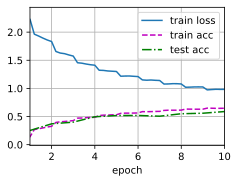

In [28]:
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())

### 改了一下非线性函数的LeNet

In [14]:
net = nn.Sequential(
    nn.Conv2d(3, 6, kernel_size=5, padding=2), nn.ReLU(),   #32x32
    nn.AvgPool2d(kernel_size=2, stride=2),       #16x16
    nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(), #12x12
    nn.AvgPool2d(kernel_size=2, stride=2),    #6x6
    nn.Flatten(),
    nn.Linear(16 * 6 * 6, 120), nn.ReLU(),
    nn.Linear(120, 84), nn.ReLU(),
    nn.Linear(84, 10))

loss 0.797, train acc 0.718, test acc 0.610
17532.1 examples/sec on cuda:0


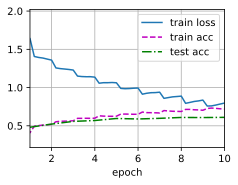

In [15]:
lr, num_epochs = 0.05, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())

### AlexNet

In [ ]:
net=nn.Sequential(
    nn.Conv2d(3,96,kernel_size=11,stride=4,padding=1),nn.ReLU(),
    nn.MaxPool2d(kernel_size=3,stride=2),
    nn.Conv2d(96,256,kernel_size=5,padding=2),nn.ReLU(),
    nn.MaxPool2d(kernel_size=3,stride=2),
    nn.Conv2d(256,384,kernel_size=3,padding=1),nn.ReLU(),
    nn.Conv2d(384,384,kernel_size=3,padding=1),nn.ReLU(),
    nn.Conv2d(384,256,kernel_size=3,padding=1),nn.ReLU(),
    nn.MaxPool2d(kernel_size=3,stride=2),
    nn.Flatten(),
    nn.Linear(6400,4096),nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096,4096),nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096,10))



#原Alex net需要224大小的图片，不适配于这个数据集，过大的卷积层会使图像失去特征。故对卷积层进行了一个修改

In [16]:
net=nn.Sequential(nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1), nn.ReLU(),
nn.MaxPool2d(kernel_size=2, stride=2), # 32 -> 16
        
        # 第二层：保持 5x5，增加通道数
nn.Conv2d(64, 192, kernel_size=5, padding=2), nn.ReLU(),
nn.MaxPool2d(kernel_size=2, stride=2), # 16 -> 8
        
        # 第三、四、五层：连续卷积提取高阶特征
nn.Conv2d(192, 384, kernel_size=3, padding=1), nn.ReLU(),
nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(),
nn.MaxPool2d(kernel_size=2, stride=2), # 8 -> 4
        
nn.Flatten(),
# 此时特征图大小是 256 * 4 * 4
nn.Linear(256 * 4 * 4, 512), nn.ReLU(), nn.Dropout(p=0.5),
nn.Linear(512, 512), nn.ReLU(), nn.Dropout(p=0.5),
nn.Linear(512, 10))

loss 0.612, train acc 0.788, test acc 0.770
1807.2 examples/sec on cuda:0


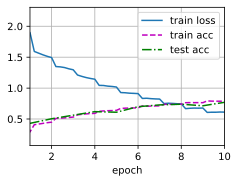

In [17]:
lr,num_epochs=0.01,10
train_ch6(net,train_iter,test_iter,num_epochs,lr,try_gpu())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


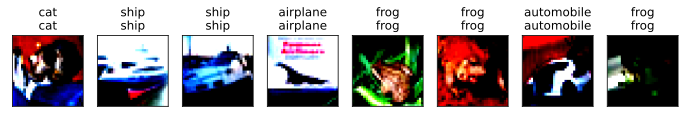

In [18]:
import matplotlib.pyplot as plt

def predict_ch3(net, test_iter, n=6):  # 默认展示 6 张图
    """预测标签（定义见第3章）"""
    for X, y in test_iter:
        break # 只取第一个批次
    
    # 拿到预测结果
    net.eval() # 评估模式，关闭 Dropout
    with torch.no_grad():
        X = X.to(d2l.try_gpu())
        output = net(X)
        preds = output.argmax(axis=1)
    
    # 转换回 CPU 供可视化使用
    X, y, preds = X.cpu(), y.cpu(), preds.cpu()
    
    # 获取标签的文字说明（CIFAR-10 的类别名称）
    labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
              'dog', 'frog', 'horse', 'ship', 'truck']
    
    titles = [labels[true] + '\n' + labels[pred] for true, pred in zip(y, preds)]
    
    # 展示前 n 张图片
    # 注意：X[i] 形状是 (3, 32, 32)，显示前需 permute 为 (32, 32, 3)
    # 同时因为之前做了 Normalize，这里为了视觉效果可以简单做一个反向处理
    imgs = [X[i].permute(1, 2, 0) for i in range(n)]
    
    d2l.show_images(imgs, 1, n, titles=titles[0:n])

# 调用展示
predict_ch3(net, test_iter, n=8)

### NiN网络

In [19]:
def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
    nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
    nn.ReLU(),
    nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
    nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU())

In [21]:
net=nn.Sequential(
        # 块 1：适配 32x32。将原本步幅 4 改为 1
        nin_block(3, 96, kernel_size=3, strides=1, padding=1),
        nn.MaxPool2d(3, stride=2, padding=1), # 32 -> 16
        
        # 块 2
        nin_block(96, 256, kernel_size=5, strides=1, padding=2),
        nn.MaxPool2d(3, stride=2, padding=1), # 16 -> 8
        
        # 块 3
        nin_block(256, 384, kernel_size=3, strides=1, padding=1),
        nn.MaxPool2d(3, stride=2, padding=1), # 8 -> 4
        
        nn.Dropout(0.5),
        
        # 块 4：关键点！最后一层输出通道数必须等于类别数 (CIFAR-10 是 10)
        nin_block(384, 10, kernel_size=3, strides=1, padding=1),
        
        # 全局平均池化 (GAP)：将 4x4 的特征图压成 1x1
        nn.AdaptiveAvgPool2d((1, 1)),
        # 将四维输出 (batch, 10, 1, 1) 转为二维 (batch, 10)
        nn.Flatten()
    )

In [23]:
X = torch.rand(size=(1, 3, 32, 32))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 96, 32, 32])
MaxPool2d output shape:	 torch.Size([1, 96, 16, 16])
Sequential output shape:	 torch.Size([1, 256, 16, 16])
MaxPool2d output shape:	 torch.Size([1, 256, 8, 8])
Sequential output shape:	 torch.Size([1, 384, 8, 8])
MaxPool2d output shape:	 torch.Size([1, 384, 4, 4])
Dropout output shape:	 torch.Size([1, 384, 4, 4])
Sequential output shape:	 torch.Size([1, 10, 4, 4])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


loss 0.596, train acc 0.793, test acc 0.716
3637.2 examples/sec on cuda:0


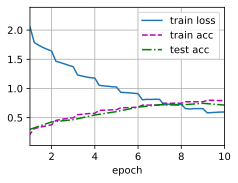

In [24]:
lr, num_epochs, batch_size = 0.1, 10, 128

train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())

### Resnet

In [25]:
from torch.nn import functional as F

class Residual(nn.Module):  
    def __init__(self, input_channels, num_channels, use_1x1conv=False,
                 strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels, kernel_size=3,
                               padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels, kernel_size=3,
                               padding=1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

In [26]:
b1 = nn.Sequential(nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
                   nn.BatchNorm2d(64), nn.ReLU(),
                   )


def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(
                Residual(input_channels, num_channels, use_1x1conv=True,
                         strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk

b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))  #*是将list展开
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))

In [28]:
net = nn.Sequential(b1, b2, b3, b4, b5, nn.AdaptiveAvgPool2d((1, 1)),
                    nn.Flatten(), nn.Linear(512, 10))

In [29]:
X = torch.rand(size=(1, 3, 32, 32))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 32, 32])
Sequential output shape:	 torch.Size([1, 64, 32, 32])
Sequential output shape:	 torch.Size([1, 128, 16, 16])
Sequential output shape:	 torch.Size([1, 256, 8, 8])
Sequential output shape:	 torch.Size([1, 512, 4, 4])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 512, 1, 1])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


loss 0.061, train acc 0.979, test acc 0.821
1819.9 examples/sec on cuda:0


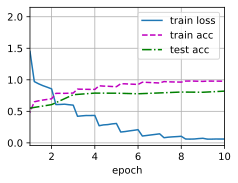

In [30]:
lr, num_epochs, batch_size = 0.1, 10, 128

train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


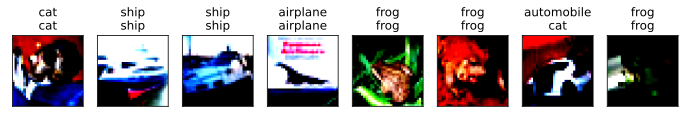

In [31]:
def predict_ch3(net, test_iter, n=6):  # 默认展示 6 张图
    """预测标签（定义见第3章）"""
    for X, y in test_iter:
        break # 只取第一个批次
    
    # 拿到预测结果
    net.eval() # 评估模式，关闭 Dropout
    with torch.no_grad():
        X = X.to(d2l.try_gpu())
        output = net(X)
        preds = output.argmax(axis=1)
    
    # 转换回 CPU 供可视化使用
    X, y, preds = X.cpu(), y.cpu(), preds.cpu()
    
    # 获取标签的文字说明（CIFAR-10 的类别名称）
    labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
              'dog', 'frog', 'horse', 'ship', 'truck']
    
    titles = [labels[true] + '\n' + labels[pred] for true, pred in zip(y, preds)]
    
    # 展示前 n 张图片
    # 注意：X[i] 形状是 (3, 32, 32)，显示前需 permute 为 (32, 32, 3)
    # 同时因为之前做了 Normalize，这里为了视觉效果可以简单做一个反向处理
    imgs = [X[i].permute(1, 2, 0) for i in range(n)]
    
    d2l.show_images(imgs, 1, n, titles=titles[0:n])

# 调用展示
predict_ch3(net, test_iter, n=8)